# p5-эксперимент на функциях пакета + зоопарк моделей (timm)

Ноутбук использует уже написанные модули пакета `5th-polynom-exps`:

| модуль | что берём |
|---|---|
| `config` | `CFG` — все параметры |
| `main` | `precompute_features`, `build_index`, `split_by_video`, `compute_norm`, `n_channels`, `make_loss` |
| `datasets` | `DatasetAnyChannels`, `Modes` |
| `model` | `SmallCNN` |
| `engine` | `fit` — обучение с логами в `runs/` |
| `train` | `evaluate` |

Плюс **зоопарк CNN из timm** (resnet/efficientnet/mobilenet/convnext…) с общим входом
`n_channels(MODE)` и сравнением по F1/accuracy. Всё обучение логируется в `runs/<ts>_<tag>/`.

## 1. Импорты (подключаем пакет)

In [1]:
import sys, os
from pathlib import Path

# Явная подсказка пути к пакету — на случай, если рабочая папка ядра была
# перемещена/удалена (тогда os.getcwd() падает FileNotFoundError).
PKG_HINT = Path.home() / "Documents" / "thermal-control-ya-project" / "5th-polynom-exps"

def _candidates():
    bases = []
    try:
        bases.append(Path(os.getcwd()))                 # может упасть, если cwd удалён
    except OSError:
        pass
    try:                                                # стартовые папки IPython
        bases += [Path(p) for p in get_ipython().user_ns.get("_dh", [])]
    except Exception:
        pass
    bases += [PKG_HINT, PKG_HINT.parent]
    out = []
    for b in bases:
        for c in [b, *b.parents, b / "5th-polynom-exps"]:
            if c not in out:
                out.append(c)
    return out

def _find_pkg():
    for c in _candidates():
        try:
            if (c / "config.py").exists():
                return c
        except OSError:
            continue
    raise FileNotFoundError(
        "config.py не найден. Скорее всего рабочая папка ядра была перемещена — "
        "перезапустите ядро (Kernel → Restart) или впишите путь в PKG_HINT.")

PKG = _find_pkg()
if str(PKG) not in sys.path:
    sys.path.insert(0, str(PKG))
os.chdir(PKG)                                           # фиксируем валидный cwd
print("пакет:", PKG)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from torch.utils.data import DataLoader
from sklearn.metrics import ConfusionMatrixDisplay

from config import CFG
from datasets import DatasetAnyChannels, Modes
from model import SmallCNN
from engine import fit
from train import evaluate
from main import (precompute_features, build_index, split_by_video,
                  compute_norm, n_channels, make_loss)

DEVICE = ("cuda" if torch.cuda.is_available()
          else "mps" if torch.backends.mps.is_available() else "cpu")
CLASS_NAMES = CFG.classes.class_names
print("device:", DEVICE)

пакет: /Users/tomatocoder/Documents/thermal-control-ya-project/5th-polynom-exps
device: mps


### Текущая конфигурация

In [6]:
print("data_dir  :", CFG.paths.data_dir)
print("mask_dir  :", CFG.paths.mask_dir)
print("feature_dir:", CFG.paths.feature_dir)
print("classes   :", CFG.classes.n_classes, CLASS_NAMES)
print("crop      :", CFG.crop.crop, "| n_bg:", CFG.crop.n_bg_per_video)
print("train     :", CFG.train.model_dump())

data_dir  : /Users/tomatocoder/Documents/thermal-control-ya-project/datasets/dataset_kaggle/data
mask_dir  : /Users/tomatocoder/Documents/thermal-control-ya-project/datasets/dataset_kaggle/labels/automated_mask
feature_dir: /Users/tomatocoder/Documents/thermal-control-ya-project/features_p5
classes   : 6 ['фон', '0.5', '1.0', '1.5', '2.0', '2.5']
crop      : 48 | n_bg: 8
train     : {'batch_size': 64, 'epochs': 400, 'learning_rate': 0.001, 'n_test_videos': 10, 'max_videos': None, 'loss_name': 'ce', 'seed': 67}


## 2. Подготовка данных (функциями `main.py`)

`precompute_features` считает TSR-признаки (полином 5°) в кэш, `build_index` режет
кропы по маскам, `split_by_video` делит без утечки, `compute_norm` — μ/σ по train.

In [7]:
precompute_features()                    # TSR-кэш (один раз; готовые пропускаются)

index = build_index()
train_idx, test_idx = split_by_video(index)
mean, std = compute_norm(train_idx)
print(f"кропов: {len(index)} | train: {len(train_idx)} | test: {len(test_idx)}")

import collections
cnt = collections.Counter(l for *_, l in index)
print("по классам:", {CLASS_NAMES[k]: cnt.get(k, 0) for k in range(CFG.classes.n_classes)})

кропов: 680 | train: 509 | test: 171
по классам: {'фон': 304, '0.5': 86, '1.0': 89, '1.5': 67, '2.0': 65, '2.5': 69}


### Датасеты и лоадеры (`DatasetAnyChannels`, `Modes`)

In [15]:
MODE = Modes.p5                  # p5 | p5_d1 | p5_d1_d2
IN_CH = n_channels(MODE)
print("режим каналов:", MODE.value, "| входных каналов:", IN_CH)

train_ds = DatasetAnyChannels(train_idx, mean, std, MODE, train=True)
test_ds  = DatasetAnyChannels(test_idx,  mean, std, MODE, train=False)
train_ld = DataLoader(train_ds, batch_size=CFG.train.batch_size, shuffle=True)
test_ld  = DataLoader(test_ds,  batch_size=CFG.train.batch_size, shuffle=False)

xb, yb, *_ = next(iter(train_ld))
print("батч:", tuple(xb.shape), "метки:", tuple(yb.shape))

режим каналов: p5 | входных каналов: 6
батч: (64, 6, 48, 48) метки: (64,)


## 3. Зоопарк моделей: `SmallCNN` + разные CNN из timm

`build_model(name, in_ch, n_cls)` возвращает нашу `SmallCNN` для `"small_cnn"` или
любую сеть **timm** по имени. timm умеет `in_chans` из коробки — адаптирует первый
слой под наши `IN_CH` каналов (RGB-предобучение при этом не обязательно).

> Требуется `pip install timm`. Предобучение (`pretrained=True`) скачивает веса из сети;
> при офлайне ставьте `PRETRAINED=False`.

In [20]:
def build_model(name, in_ch=IN_CH, n_cls=CFG.classes.n_classes, pretrained=False):
    if name == "small_cnn":
        return SmallCNN(in_channels=in_ch, n_cls=n_cls)
    import timm                                   # pip install timm
    return timm.create_model(name, in_chans=in_ch, num_classes=n_cls,
                             pretrained=pretrained)

# Набор для сравнения (лёгкие CNN, ок для 48×48 и малых данных)
MODEL_ZOO = [
    "small_cnn",
    "resnet18",
    "resnet34",
    "convnext_nano",
]
PRETRAINED = True                                # True — качает веса ImageNet
print("модели:", MODEL_ZOO)

модели: ['small_cnn', 'resnet18', 'resnet34', 'convnext_nano']


## 4. Обучение всех моделей и сравнение

Каждую модель обучаем через `engine.fit` (пишет логи/метрики в `runs/<ts>_<tag>/`),
лосс берётся из `CFG.train.loss_name`. Для сравнения число эпох временно уменьшаем
(`SWEEP_EPOCHS`), иначе `CFG.train.epochs` может быть очень большим.

In [21]:
SWEEP_EPOCHS = 30
CFG.train.epochs = SWEEP_EPOCHS                   # временно на время сравнения

def train_one(name):
    torch.manual_seed(CFG.train.seed)
    model = build_model(name, pretrained=PRETRAINED).to(DEVICE)
    loss_fn = make_loss(train_idx).to(DEVICE)
    opt = torch.optim.Adam(model.parameters(), lr=CFG.train.learning_rate)
    tag = f"{MODE.value}_{name}_{CFG.train.loss_name}"
    run_dir, _, result = fit(train_ld, model, loss_fn, opt, DEVICE,
                             val_loader=test_ld, tag=tag)
    f1, acc, cm = evaluate(test_ld, model, DEVICE)   # для матрицы ошибок
    return dict(model=name, params=sum(p.numel() for p in model.parameters()),
                f1=float(f1), acc=float(acc), cm=cm, run_dir=str(run_dir))

results = []
for name in MODEL_ZOO:
    try:
        r = train_one(name)
        print(f"{name:22} params={r['params']:>9,}  F1={r['f1']:.3f}  acc={r['acc']:.3f}")
        results.append(r)
    except Exception as e:
        print(f"{name:22} ПРОПУЩЕНА: {type(e).__name__}: {e}")

df = pd.DataFrame([{k: v for k, v in r.items() if k != "cm"} for r in results])
df.sort_values("f1", ascending=False)

START tag=%s device=%s epochs=%d lr=%s params=%d p5_small_cnn_ce mps 30 0.001 24406
epoch   1/30 | train_loss 1.7463 | val_f1 0.1062 | val_acc 0.4678
epoch   2/30 | train_loss 1.6653 | val_f1 0.1062 | val_acc 0.4678
epoch   3/30 | train_loss 1.6184 | val_f1 0.1062 | val_acc 0.4678
epoch   4/30 | train_loss 1.5683 | val_f1 0.1062 | val_acc 0.4678
epoch   5/30 | train_loss 1.5299 | val_f1 0.1062 | val_acc 0.4678
epoch   6/30 | train_loss 1.5137 | val_f1 0.1062 | val_acc 0.4678
epoch   7/30 | train_loss 1.5040 | val_f1 0.1062 | val_acc 0.4678
epoch   8/30 | train_loss 1.4975 | val_f1 0.1062 | val_acc 0.4678
epoch   9/30 | train_loss 1.4899 | val_f1 0.1062 | val_acc 0.4678
epoch  10/30 | train_loss 1.4869 | val_f1 0.1062 | val_acc 0.4678
epoch  11/30 | train_loss 1.4849 | val_f1 0.1062 | val_acc 0.4678
epoch  12/30 | train_loss 1.4761 | val_f1 0.1062 | val_acc 0.4678
epoch  13/30 | train_loss 1.4638 | val_f1 0.1067 | val_acc 0.4678
epoch  14/30 | train_loss 1.4576 | val_f1 0.1067 | val_acc

model.safetensors: reconstructing file:   0%|          |  0.00B / 87.3MB            

model.safetensors: downloading bytes:           |  0.00B            

START tag=%s device=%s epochs=%d lr=%s params=%d p5_resnet34_ce mps 30 0.001 21297158
epoch   1/30 | train_loss 1.7001 | val_f1 0.1062 | val_acc 0.4678
epoch   2/30 | train_loss 1.4190 | val_f1 0.1236 | val_acc 0.4737
epoch   3/30 | train_loss 1.2559 | val_f1 0.2380 | val_acc 0.5263
epoch   4/30 | train_loss 1.1114 | val_f1 0.3955 | val_acc 0.6082
epoch   5/30 | train_loss 0.9069 | val_f1 0.5775 | val_acc 0.6959
epoch   6/30 | train_loss 0.7416 | val_f1 0.5584 | val_acc 0.6784
epoch   7/30 | train_loss 0.5875 | val_f1 0.6419 | val_acc 0.7251
epoch   8/30 | train_loss 0.4673 | val_f1 0.6706 | val_acc 0.7485
epoch   9/30 | train_loss 0.3953 | val_f1 0.5622 | val_acc 0.7135
epoch  10/30 | train_loss 0.2989 | val_f1 0.7526 | val_acc 0.8070
epoch  11/30 | train_loss 0.2651 | val_f1 0.7503 | val_acc 0.8129
epoch  12/30 | train_loss 0.2171 | val_f1 0.6643 | val_acc 0.7661
epoch  13/30 | train_loss 0.2203 | val_f1 0.5877 | val_acc 0.7251
epoch  14/30 | train_loss 0.2285 | val_f1 0.7426 | val_a

model.safetensors: reconstructing file:   0%|          |  0.00B / 62.4MB            

model.safetensors: downloading bytes:           |  0.00B            

START tag=%s device=%s epochs=%d lr=%s params=%d p5_convnext_nano_ce mps 30 0.001 14960246
epoch   1/30 | train_loss 2.6888 | val_f1 0.1062 | val_acc 0.4678
epoch   2/30 | train_loss 1.6353 | val_f1 0.1062 | val_acc 0.4678
epoch   3/30 | train_loss 1.6346 | val_f1 0.1062 | val_acc 0.4678
epoch   4/30 | train_loss 1.6027 | val_f1 0.1062 | val_acc 0.4678
epoch   5/30 | train_loss 1.6216 | val_f1 0.1062 | val_acc 0.4678
epoch   6/30 | train_loss 1.5690 | val_f1 0.1062 | val_acc 0.4678
epoch   7/30 | train_loss 1.5384 | val_f1 0.1062 | val_acc 0.4678
epoch   8/30 | train_loss 1.5164 | val_f1 0.1062 | val_acc 0.4678
epoch   9/30 | train_loss 1.5059 | val_f1 0.1062 | val_acc 0.4678
epoch  10/30 | train_loss 1.4988 | val_f1 0.1203 | val_acc 0.4737
epoch  11/30 | train_loss 1.4994 | val_f1 0.1264 | val_acc 0.4620
epoch  12/30 | train_loss 1.4771 | val_f1 0.1062 | val_acc 0.4678
epoch  13/30 | train_loss 1.4951 | val_f1 0.1062 | val_acc 0.4678
epoch  14/30 | train_loss 1.4619 | val_f1 0.1281 | 

,model,params,f1,acc,run_dir
2,resnet34,21297158,0.796673,0.818713,/Users/tomatocoder/Documents/thermal-control-y...
1,resnet18,11188998,0.751186,0.818713,/Users/tomatocoder/Documents/thermal-control-y...
3,convnext_nano,14960246,0.105191,0.450292,/Users/tomatocoder/Documents/thermal-control-y...
0,small_cnn,24406,0.102881,0.438596,/Users/tomatocoder/Documents/thermal-control-y...


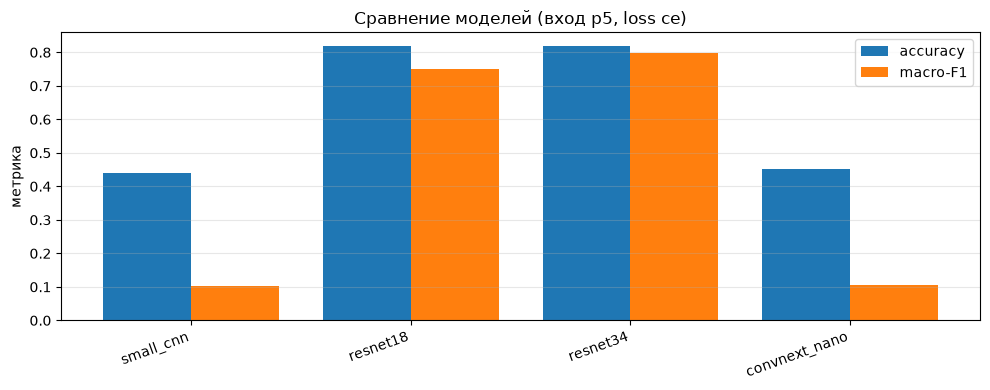

In [22]:
# Диаграмма сравнения моделей
if len(df):
    x = np.arange(len(df)); w = 0.4
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.bar(x - w/2, df["acc"], w, label="accuracy")
    ax.bar(x + w/2, df["f1"],  w, label="macro-F1")
    ax.set_xticks(x); ax.set_xticklabels(df["model"], rotation=20, ha="right")
    ax.set_ylabel("метрика"); ax.set_title(f"Сравнение моделей (вход {MODE.value}, loss {CFG.train.loss_name})")
    ax.legend(); ax.grid(axis="y", alpha=.3); plt.tight_layout(); plt.show()

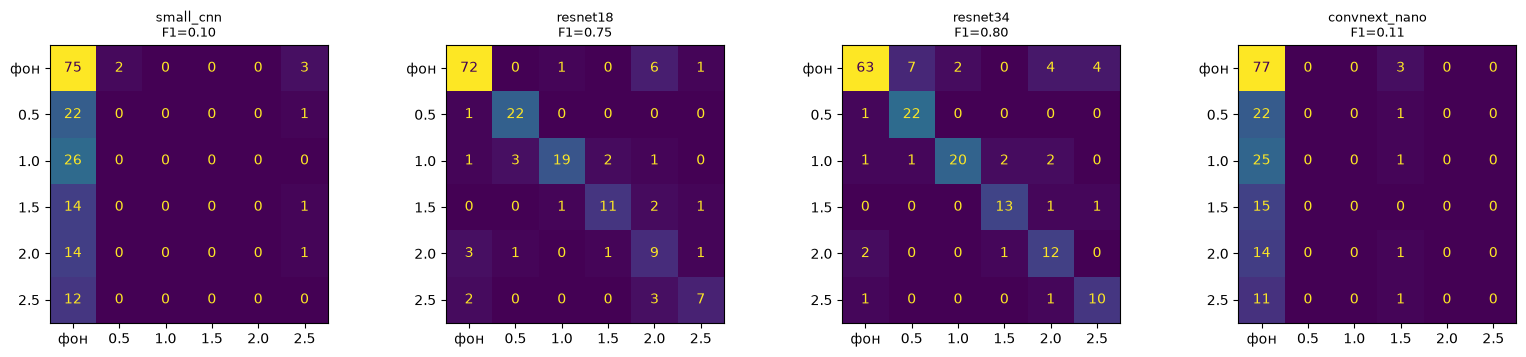

In [23]:
# Confusion-матрицы всех обученных моделей
if results:
    fig, axs = plt.subplots(1, len(results), figsize=(4*len(results), 3.6))
    for ax, r in zip(np.atleast_1d(axs), results):
        ConfusionMatrixDisplay(r["cm"], display_labels=CLASS_NAMES).plot(
            ax=ax, cmap="viridis", colorbar=False, values_format="d")
        ax.set_title(f"{r['model']}\nF1={r['f1']:.2f}", fontsize=9)
        ax.set_xlabel(""); ax.set_ylabel("")
    plt.tight_layout(); plt.show()

## 5. Как менять эксперимент

- **Набор каналов** — переменная `MODE` (`Modes.p5` / `p5_d1` / `p5_d1_d2`);
  число входных каналов подхватывается через `n_channels(MODE)`.
- **Лосс** — `config.yaml → train.loss_name` (`ce` / `weighted_ce` / `label_smooth`),
  реализация в `losses.Losses`, выбор — `make_loss`.
- **Список моделей** — `MODEL_ZOO` (любые имена timm) + `PRETRAINED`.
- **Число эпох** — `SWEEP_EPOCHS` для сравнения, боевое значение в `config.yaml → train.epochs`.
- Все прогоны логируются в `runs/<timestamp>_<tag>/` (`metrics.csv`, `results.json`,
  `confusion.csv`, `config.yaml`) — удобно сравнивать постфактум.

**Зависимости:** `torch`, `timm`, `pydantic`, `pyyaml`, `scipy`, `scikit-learn`, `Pillow`.

## 6. Полная сетка экспериментов

Перебор по осям:

| ось | значения |
|---|---|
| модель | `small_cnn`, `resnet18`, `resnet34`, `convnext_nano` |
| предобучка | без (`False`) и с (`True`) — только для timm; `small_cnn` всегда без |
| каналы | `p5`, `p5+d1`, `p5+d1+d2` |
| эпохи | 30, 50, 100 |
| лосс | `ce`, `weighted_ce` |

Каждый прогон обучается через `engine.fit` и логируется в `runs/<ts>_<tag>/`
(`metrics.csv`, `results.json`, `confusion.csv`). Итог — сводная таблица метрик и
confusion-карты лучших конфигураций.

> ⚠️ Полная сетка ≈ **126 прогонов** (эпохи до 100) — на CPU это **часы**.
> Для проверки поставьте `QUICK = True` (маленькое подмножество и мало эпох).
> `pretrained=True` скачивает веса ImageNet — нужен интернет (иначе конфигурация
> пропускается через try/except).

In [25]:
import itertools, time

# ── Оси сетки ────────────────────────────────────────────────────────────────
MODELS          = ["small_cnn", "resnet18", "resnet34", "convnext_nano"]
PRETRAINED_OPTS = [False, True]
MODES_GRID      = [Modes.p5, Modes.p5_d1, Modes.p5_d1_d2]
EPOCHS_GRID     = [30, 50, 100]
LOSSES_GRID     = ["ce", "weighted_ce"]

QUICK = False                      # True — быстрый прогон подмножества (проверка)
if QUICK:
    MODELS          = ["small_cnn", "resnet18"]
    PRETRAINED_OPTS = [False]
    MODES_GRID      = [Modes.p5, Modes.p5_d1_d2]
    EPOCHS_GRID     = [3]
    LOSSES_GRID     = ["ce", "weighted_ce"]

# Лоадеры на каждый режим каналов (mean/std общие — считаются по 6 коэффициентам)
loaders = {}
for m in MODES_GRID:
    tr = DatasetAnyChannels(train_idx, mean, std, m, train=True)
    te = DatasetAnyChannels(test_idx,  mean, std, m, train=False)
    loaders[m] = (DataLoader(tr, batch_size=CFG.train.batch_size, shuffle=True),
                  DataLoader(te, batch_size=CFG.train.batch_size, shuffle=False))

# Комбинации; у small_cnn нет предобучки → оставляем только pretrained=False
grid = [g for g in itertools.product(MODELS, PRETRAINED_OPTS, MODES_GRID,
                                     EPOCHS_GRID, LOSSES_GRID)
        if not (g[0] == "small_cnn" and g[1] is True)]
print("конфигураций в сетке:", len(grid))

конфигураций в сетке: 126


In [26]:
def run_cell(model_name, pretrained, mode, epochs, loss_name):
    CFG.train.epochs = epochs                 # эти два поля читают fit/train и make_loss
    CFG.train.loss_name = loss_name
    torch.manual_seed(CFG.train.seed)
    net = build_model(model_name, in_ch=n_channels(mode), pretrained=pretrained).to(DEVICE)
    loss_fn = make_loss(train_idx).to(DEVICE)
    opt = torch.optim.Adam(net.parameters(), lr=CFG.train.learning_rate)
    tr_ld, te_ld = loaders[mode]
    tag = f"{model_name}_{mode.value}_pt{int(pretrained)}_e{epochs}_{loss_name}"
    run_dir, _, _ = fit(tr_ld, net, loss_fn, opt, DEVICE, val_loader=te_ld, tag=tag)
    f1, acc, cm = evaluate(te_ld, net, DEVICE)
    return dict(model=model_name, pretrained=pretrained, mode=mode.value,
                epochs=epochs, loss=loss_name, f1=float(f1), acc=float(acc),
                params=sum(p.numel() for p in net.parameters()),
                run_dir=str(run_dir), cm=cm)

results = []
t_all = time.time()
for i, (mn, pt, md_, ep, ls) in enumerate(grid, 1):
    t0 = time.time()
    try:
        r = run_cell(mn, pt, md_, ep, ls)
        results.append(r)
        print(f"[{i:3d}/{len(grid)}] {mn:14} {md_.value:9} pt={int(pt)} e={ep:3d} {ls:11} "
              f"-> F1={r['f1']:.3f} acc={r['acc']:.3f}  ({time.time()-t0:.0f}s)")
    except Exception as e:
        print(f"[{i:3d}/{len(grid)}] SKIP {mn} {md_.value} pt={int(pt)} e={ep} {ls}: "
              f"{type(e).__name__}: {e}")
print(f"\nвсего: {len(results)}/{len(grid)} за {(time.time()-t_all)/60:.1f} мин")

START tag=%s device=%s epochs=%d lr=%s params=%d small_cnn_p5_pt0_e30_ce mps 30 0.001 24406
epoch   1/30 | train_loss 1.7463 | val_f1 0.1062 | val_acc 0.4678
epoch   2/30 | train_loss 1.6653 | val_f1 0.1062 | val_acc 0.4678
epoch   3/30 | train_loss 1.6184 | val_f1 0.1062 | val_acc 0.4678
epoch   4/30 | train_loss 1.5683 | val_f1 0.1062 | val_acc 0.4678
epoch   5/30 | train_loss 1.5299 | val_f1 0.1062 | val_acc 0.4678
epoch   6/30 | train_loss 1.5137 | val_f1 0.1062 | val_acc 0.4678
epoch   7/30 | train_loss 1.5040 | val_f1 0.1062 | val_acc 0.4678
epoch   8/30 | train_loss 1.4975 | val_f1 0.1062 | val_acc 0.4678
epoch   9/30 | train_loss 1.4899 | val_f1 0.1062 | val_acc 0.4678
epoch  10/30 | train_loss 1.4869 | val_f1 0.1062 | val_acc 0.4678
epoch  11/30 | train_loss 1.4849 | val_f1 0.1062 | val_acc 0.4678
epoch  12/30 | train_loss 1.4761 | val_f1 0.1062 | val_acc 0.4678
epoch  13/30 | train_loss 1.4638 | val_f1 0.1067 | val_acc 0.4678
epoch  14/30 | train_loss 1.4576 | val_f1 0.1067 |

In [28]:
# Сводная таблица + сохранение на диск
dfg = pd.DataFrame([{k: v for k, v in r.items() if k != "cm"} for r in results])
out_csv = CFG.paths.log_dir / "grid_results.csv"
CFG.paths.log_dir.mkdir(parents=True, exist_ok=True)
dfg.to_csv(out_csv, index=False)
print("сохранено:", out_csv)
dfg.sort_values("f1", ascending=False).head(20)

сохранено: /Users/tomatocoder/Documents/thermal-control-ya-project/runs/grid_results.csv


,model,pretrained,mode,epochs,loss,f1,acc,params,run_dir
95,convnext_nano,False,p5,100,weighted_ce,0.924500,0.929825,14960246,/Users/tomatocoder/Documents/thermal-control-y...
94,convnext_nano,False,p5,100,ce,0.923936,0.941520,14960246,/Users/tomatocoder/Documents/thermal-control-y...
93,convnext_nano,False,p5,50,weighted_ce,0.917334,0.923977,14960246,/Users/tomatocoder/Documents/thermal-control-y...
101,convnext_nano,False,p5+d1,100,weighted_ce,0.913306,0.935673,14966646,/Users/tomatocoder/Documents/thermal-control-y...
99,convnext_nano,False,p5+d1,50,weighted_ce,0.911002,0.929825,14966646,/Users/tomatocoder/Documents/thermal-control-y...
100,convnext_nano,False,p5+d1,100,ce,0.883105,0.923977,14966646,/Users/tomatocoder/Documents/thermal-control-y...
76,resnet34,True,p5,100,ce,0.880157,0.906433,21297158,/Users/tomatocoder/Documents/thermal-control-y...
18,resnet18,False,p5,30,ce,0.879294,0.906433,11188998,/Users/tomatocoder/Documents/thermal-control-y...
80,resnet34,True,p5+d1,50,ce,0.875455,0.906433,21312838,/Users/tomatocoder/Documents/thermal-control-y...
105,convnext_nano,False,p5+d1+d2,50,weighted_ce,0.873553,0.906433,14971766,/Users/tomatocoder/Documents/thermal-control-y...


### Основные метрики: срезы по каждой оси (средний macro-F1)

In [29]:
if len(dfg):
    for col in ["model", "mode", "pretrained", "epochs", "loss"]:
        s = dfg.groupby(col)["f1"].mean().sort_values(ascending=False)
        print(f"— средний F1 по '{col}':")
        for k, v in s.items():
            print(f"     {str(k):14} {v:.3f}")
        print()
    best = dfg.sort_values("f1", ascending=False).iloc[0]
    print("ЛУЧШАЯ КОНФИГУРАЦИЯ:")
    print(best[["model", "mode", "pretrained", "epochs", "loss", "f1", "acc"]].to_string())

— средний F1 по 'model':
     resnet34       0.827
     resnet18       0.807
     convnext_nano  0.549
     small_cnn      0.358

— средний F1 по 'mode':
     p5+d1+d2       0.691
     p5             0.676
     p5+d1          0.659

— средний F1 по 'pretrained':
     False          0.722
     True           0.613

— средний F1 по 'epochs':
     100            0.714
     50             0.678
     30             0.633

— средний F1 по 'loss':
     ce             0.682
     weighted_ce    0.668

ЛУЧШАЯ КОНФИГУРАЦИЯ:
model         convnext_nano
mode                     p5
pretrained            False
epochs                  100
loss            weighted_ce
f1                   0.9245
acc                0.929825


In [30]:
# Диаграмма топ-15 конфигураций по F1
if len(dfg):
    top = dfg.sort_values("f1", ascending=False).head(15).iloc[::-1]
    labels = [f"{r.model}|{r['mode']}|pt{int(r.pretrained)}|e{r.epochs}|{r.loss}"
              for r in top.itertuples()]
    plt.figure(figsize=(9, 6))
    plt.barh(range(len(top)), top["f1"])
    plt.yticks(range(len(top)), labels, fontsize=7)
    plt.xlabel("macro-F1"); plt.title("Топ-15 конфигураций (test)")
    plt.grid(axis="x", alpha=.3); plt.tight_layout(); plt.show()

TypeError: tuple indices must be integers or slices, not str

### Confusion-карты лучших конфигураций

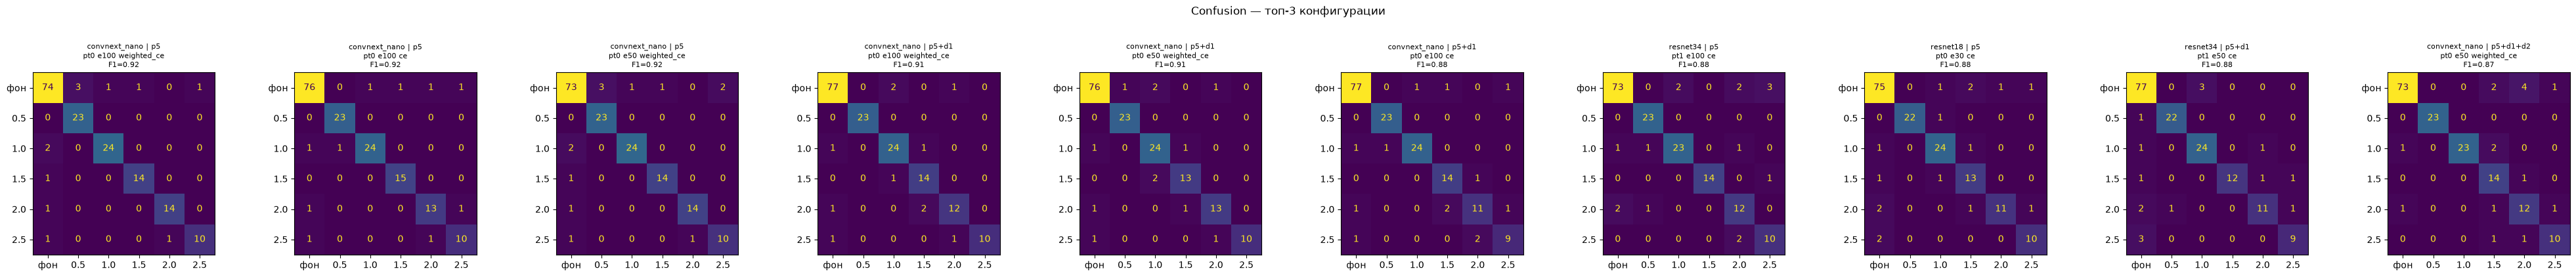

In [35]:
top_runs = sorted(results, key=lambda r: -r["f1"])[:10]
if top_runs:
    fig, axs = plt.subplots(1, len(top_runs), figsize=(4*len(top_runs), 3.8))
    for ax, r in zip(np.atleast_1d(axs), top_runs):
        ConfusionMatrixDisplay(r["cm"], display_labels=CLASS_NAMES).plot(
            ax=ax, cmap="viridis", colorbar=False, values_format="d")
        ax.set_title(f"{r['model']} | {r['mode']}\npt{int(r['pretrained'])} e{r['epochs']} "
                     f"{r['loss']}\nF1={r['f1']:.2f}", fontsize=8)
        ax.set_xlabel(""); ax.set_ylabel("")
    fig.suptitle("Confusion — топ-3 конфигурации", y=1.06)
    plt.tight_layout(); plt.show()

## 7. Заметки по сетке

- `grid_results.csv` (в `runs/`) содержит все конфигурации — можно анализировать
  отдельно (pivot по любой оси).
- Срезы «средний F1 по оси» показывают **вклад каждого фактора** (модель / каналы /
  предобучка / эпохи / лосс), не привязываясь к одной удачной комбинации.
- `CFG.train.epochs` и `CFG.train.loss_name` меняются в цикле — после сетки в `CFG`
  останутся значения последней конфигурации (перечитайте `config.yaml`, если нужно).
- Тяжело на CPU: начните с `QUICK = True`, затем сузьте `EPOCHS_GRID`/`MODELS`,
  или запускайте на GPU.

## 8. Целевой прогон: `convnext_nano` / `resnet34` × {p5, p5+d1} × {50, 100} × все лоссы

Прогон запрошенной конфигурации с полными метриками из модуля **`metrics.Metrics`**
(accuracy, balanced_accuracy, macro/weighted-F1, ordinal MAE, **QWK**). Каждый прогон
логируется в `runs/<ts>_<tag>/`; сводка — в `runs/grid_convnext_resnet.csv`.

Оси: **модели** {convnext_nano, resnet34} × **каналы** {`p5`, `p5+d1`} ×
**эпохи** {50, 100} × **лоссы** {ce, weighted_ce, label_smooth, cost_sensitive_ce, qwk}
= **40 прогонов**. На MPS/GPU ≈ 40–60 мин, на CPU — существенно дольше.

In [36]:
from metrics import Metrics
import itertools, time

G_MODELS     = ["convnext_nano", "resnet34"]
G_MODES      = [Modes.p5, Modes.p5_d1]          # «p2» и «p2+p1»
G_EPOCHS     = [50, 100]
G_LOSSES     = ["ce", "weighted_ce", "label_smooth", "cost_sensitive_ce", "qwk"]
G_PRETRAINED = False

# лоадеры на каждый режим каналов (mean/std посчитаны выше)
g_loaders = {}
for m in G_MODES:
    tr = DatasetAnyChannels(train_idx, mean, std, m, train=True)
    te = DatasetAnyChannels(test_idx,  mean, std, m, train=False)
    g_loaders[m] = (DataLoader(tr, batch_size=CFG.train.batch_size, shuffle=True),
                    DataLoader(te, batch_size=CFG.train.batch_size, shuffle=False))

g_combos = list(itertools.product(G_MODELS, G_MODES, G_EPOCHS, G_LOSSES))
print("прогонов:", len(g_combos))

прогонов: 40


In [37]:
g_results = []
for i, (mn, md_, ep, ls) in enumerate(g_combos, 1):
    CFG.train.epochs = ep                        # эти поля читают fit/train и make_loss
    CFG.train.loss_name = ls
    torch.manual_seed(CFG.train.seed)
    t0 = time.time()
    try:
        net = build_model(mn, in_ch=n_channels(md_), pretrained=G_PRETRAINED).to(DEVICE)
        loss_fn = make_loss(train_idx).to(DEVICE)
        opt = torch.optim.Adam(net.parameters(), lr=CFG.train.learning_rate)
        tr_ld, te_ld = g_loaders[md_]
        tag = f"{mn}_{md_.value}_e{ep}_{ls}"
        run_dir, _, _ = fit(tr_ld, net, loss_fn, opt, DEVICE, val_loader=te_ld, tag=tag)

        M = Metrics.from_loader(net, te_ld, DEVICE)      # полный набор метрик
        d = M.compute()
        g_results.append(dict(model=mn, mode=md_.value, epochs=ep, loss=ls,
                              **d, M=M, run_dir=str(run_dir)))
        print(f"[{i:2d}/{len(g_combos)}] {tag:40} acc={d['accuracy']:.3f} "
              f"f1={d['macro_f1']:.3f} qwk={d['qwk']:.3f} mae={d['ordinal_mae']:.3f} "
              f"({time.time()-t0:.0f}s)")
    except Exception as e:
        print(f"[{i:2d}/{len(g_combos)}] SKIP {mn} {md_.value} e{ep} {ls}: {type(e).__name__}: {e}")

g_df = pd.DataFrame([{k: v for k, v in r.items() if k not in ("M",)} for r in g_results])
CFG.paths.log_dir.mkdir(parents=True, exist_ok=True)
g_df.to_csv(CFG.paths.log_dir / "grid_convnext_resnet.csv", index=False)
g_df.sort_values("macro_f1", ascending=False)

START tag=%s device=%s epochs=%d lr=%s params=%d convnext_nano_p5_e50_ce mps 50 0.001 14960246
epoch   1/50 | train_loss 2.9158 | val_f1 0.1281 | val_acc 0.3860
epoch   2/50 | train_loss 1.7628 | val_f1 0.1364 | val_acc 0.3099
epoch   3/50 | train_loss 1.5208 | val_f1 0.1092 | val_acc 0.4561
epoch   4/50 | train_loss 1.4557 | val_f1 0.1528 | val_acc 0.4737
epoch   5/50 | train_loss 1.3928 | val_f1 0.1202 | val_acc 0.4503
epoch   6/50 | train_loss 1.3466 | val_f1 0.2940 | val_acc 0.5380
epoch   7/50 | train_loss 1.2559 | val_f1 0.3344 | val_acc 0.5497
epoch   8/50 | train_loss 1.1472 | val_f1 0.4291 | val_acc 0.6374
epoch   9/50 | train_loss 1.0847 | val_f1 0.3406 | val_acc 0.5673
epoch  10/50 | train_loss 0.8954 | val_f1 0.6703 | val_acc 0.7953
epoch  11/50 | train_loss 0.7469 | val_f1 0.5662 | val_acc 0.7368
epoch  12/50 | train_loss 0.6600 | val_f1 0.6118 | val_acc 0.7953
epoch  13/50 | train_loss 0.5545 | val_f1 0.6698 | val_acc 0.8129
epoch  14/50 | train_loss 0.4338 | val_f1 0.701

,model,mode,epochs,loss,accuracy,balanced_accuracy,macro_f1,weighted_f1,ordinal_mae,qwk,run_dir
8,convnext_nano,p5+d1,50,label_smooth,0.947368,0.938034,0.937824,0.947367,0.134503,0.920835,/Users/tomatocoder/Documents/thermal-control-y...
5,convnext_nano,p5,100,label_smooth,0.953216,0.928312,0.937325,0.952749,0.122807,0.924555,/Users/tomatocoder/Documents/thermal-control-y...
4,convnext_nano,p5,100,weighted_ce,0.929825,0.924679,0.924500,0.929606,0.175439,0.890775,/Users/tomatocoder/Documents/thermal-control-y...
3,convnext_nano,p5,100,ce,0.941520,0.928846,0.923936,0.941376,0.163743,0.890405,/Users/tomatocoder/Documents/thermal-control-y...
11,convnext_nano,p5+d1,100,label_smooth,0.941520,0.926923,0.922144,0.941518,0.134503,0.924540,/Users/tomatocoder/Documents/thermal-control-y...
1,convnext_nano,p5,50,weighted_ce,0.923977,0.922596,0.917334,0.923898,0.204678,0.865085,/Users/tomatocoder/Documents/thermal-control-y...
10,convnext_nano,p5+d1,100,weighted_ce,0.935673,0.908707,0.913306,0.935644,0.140351,0.918065,/Users/tomatocoder/Documents/thermal-control-y...
7,convnext_nano,p5+d1,50,weighted_ce,0.929825,0.906624,0.911002,0.929876,0.146199,0.916976,/Users/tomatocoder/Documents/thermal-control-y...
2,convnext_nano,p5,50,label_smooth,0.935673,0.892201,0.898681,0.934601,0.122807,0.932115,/Users/tomatocoder/Documents/thermal-control-y...
23,resnet34,p5+d1,100,label_smooth,0.912281,0.879078,0.884667,0.912194,0.239766,0.835326,/Users/tomatocoder/Documents/thermal-control-y...


### Срезы по осям (средний macro-F1) и лучшая конфигурация

In [38]:
if len(g_df):
    for col in ["model", "mode", "epochs", "loss"]:
        print(f"— средний macro-F1 по '{col}':")
        print(g_df.groupby(col)["macro_f1"].mean().sort_values(ascending=False)
              .round(3).to_string())
        print()
    best = g_df.sort_values("macro_f1", ascending=False).iloc[0]
    print("ЛУЧШАЯ КОНФИГУРАЦИЯ:")
    print(best[["model", "mode", "epochs", "loss",
                "accuracy", "macro_f1", "qwk", "ordinal_mae"]].to_string())

— средний macro-F1 по 'model':
model
convnext_nano    0.905
resnet34         0.836

— средний macro-F1 по 'mode':
mode
p5       0.873
p5+d1    0.868

— средний macro-F1 по 'epochs':
epochs
100    0.884
50     0.857

— средний macro-F1 по 'loss':
loss
label_smooth    0.890
weighted_ce     0.880
ce              0.841

ЛУЧШАЯ КОНФИГУРАЦИЯ:
model          convnext_nano
mode                   p5+d1
epochs                    50
loss            label_smooth
accuracy            0.947368
macro_f1            0.937824
qwk                 0.920835
ordinal_mae         0.134503


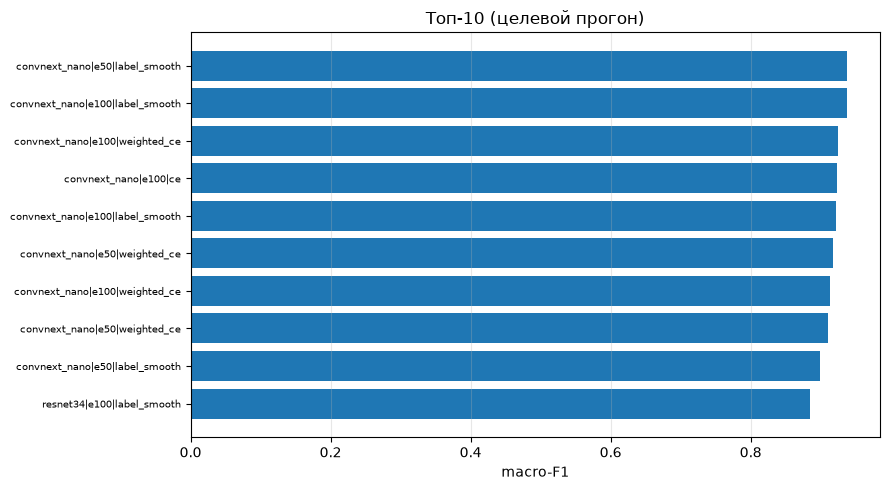

Лучший: convnext_nano p5+d1 e50 label_smooth
accuracy=0.9474 | balanced_accuracy=0.9380 | macro_f1=0.9378 | weighted_f1=0.9474 | ordinal_mae=0.1345 | qwk=0.9208
              precision    recall  f1-score   support

         фон       0.96      0.95      0.96        80
         0.5       0.96      1.00      0.98        23
         1.0       0.93      0.96      0.94        26
         1.5       0.87      0.87      0.87        15
         2.0       1.00      0.93      0.97        15
         2.5       0.92      0.92      0.92        12

    accuracy                           0.95       171
   macro avg       0.94      0.94      0.94       171
weighted avg       0.95      0.95      0.95       171



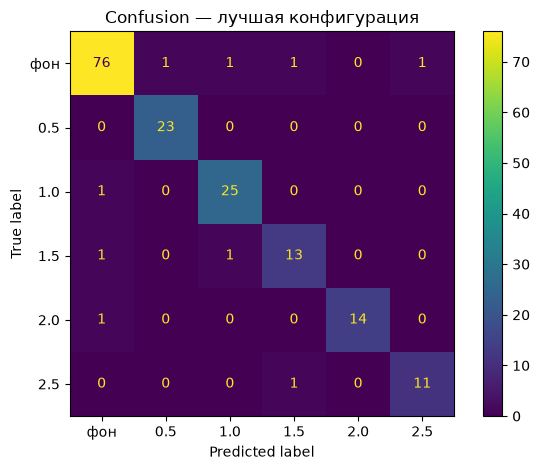

In [45]:
# Топ-10 по macro-F1 + полный отчёт (Metrics) и confusion лучшего
if g_results:
    top = g_df.sort_values("macro_f1", ascending=False).head(10).iloc[::-1]
    labels = [f"{r.model}|e{r.epochs}|{r.loss}" for r in top.itertuples()]
    plt.figure(figsize=(9, 5))
    plt.barh(range(len(top)), top["macro_f1"])
    plt.yticks(range(len(top)), labels, fontsize=7)
    plt.xlabel("macro-F1"); plt.title("Топ-10 (целевой прогон)")
    plt.grid(axis="x", alpha=.3); plt.tight_layout(); plt.show()

    best_run = max(g_results, key=lambda r: r["macro_f1"])
    print("Лучший:", best_run["model"], best_run["mode"],
          f"e{best_run['epochs']}", best_run["loss"])
    best_run["M"].summary()                          # метрики + classification_report
    ConfusionMatrixDisplay(best_run["M"].confusion(), display_labels=CLASS_NAMES).plot(
        cmap="viridis", values_format="d")
    plt.title("Confusion — лучшая конфигурация"); plt.tight_layout(); plt.show()

## 9. Заметки по целевому прогону

- Метрики берутся из **`metrics.Metrics`** — единый источник (accuracy,
  balanced_accuracy, macro/weighted-F1, **ordinal MAE**, **QWK**), плюс `per_class`
  и confusion; `best_run["M"].to_dict()` можно писать в `results.json`.
- Новые лоссы `cost_sensitive_ce` и `qwk` подключены через `make_loss` (в `main.py`) —
  выбираются по имени, как и остальные.
- `CFG.train.epochs` / `CFG.train.loss_name` меняются в цикле — после прогона в `CFG`
  останутся значения последней конфигурации.
- Перед запуском убедитесь, что не идёт параллельный прогон (например, `run_grid.py`) —
  иначе конкуренция за GPU замедлит оба.